<Figure size 640x480 with 0 Axes>

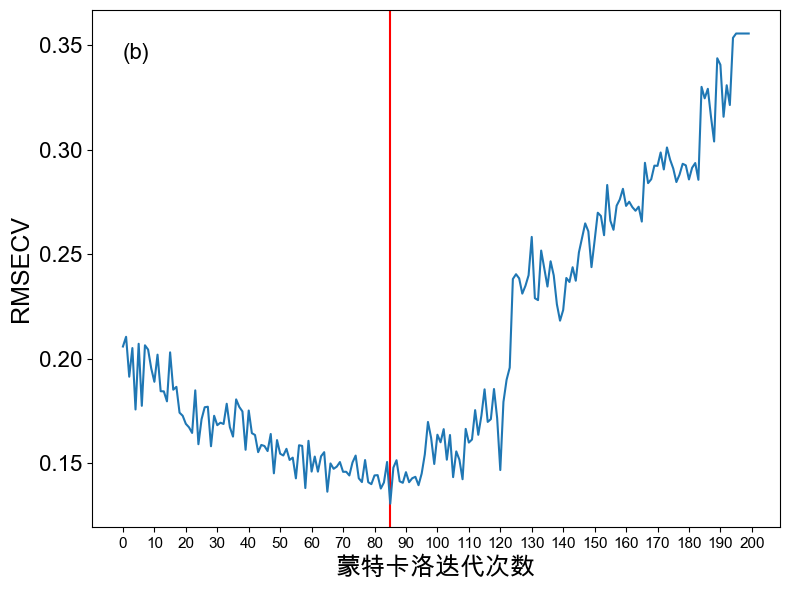

0.13066830399393442
40


In [11]:
# 设置显示中文字体，
import matplotlib.pyplot as plt
from pylab import mpl
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"] ## mac
plt.rcParams['font.family']=['Arial Unicode MS'] ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
# -*- coding: gbk -*-
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警

def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean
def CARS_Cloud(X, y, N=200, f=21, cv=10):
    p = 0.83
    m, n = X.shape
    u = np.power((n/4), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/4)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    
    x0=X
    y0=y

    WaveData = []
    # Coeff = []
    WaveNum =[]
    WaveNum2 =[]
    RMSECV = []
    r = []
    for i in range(1, N+1):
        

        rmsecv0, rindex0 = PC_Cross_Validation(x0, y0, f, cv)
        RMSECV0=Cross_Validation(x0, y0, rindex0+1, cv)

        r.append(u*np.exp(-1*k*i))
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice    \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1,-1)
        wnum = n - wave_num
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))
        if len(WaveData) == 0:
            WaveData = d
        else:
            WaveData  = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f,scale=False)
        pls.fit(xcal, ycal)
        beta = pls.coef_
        b = np.abs(beta)
        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2, :].reshape(len(b2), -1)

        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        RMSECV1=Cross_Validation(xcal, ycal, rindex+1, cv)
        
        if(RMSECV1>RMSECV0) :
            
            r.append(u*np.exp(-1*k*i))
            wave_num = int(np.round(r[i-1]*n))
            WaveNum = np.hstack((WaveNum, wave_num))
            cal_index = np.random.choice    \
                (np.arange(m), size=int(cal_num), replace=False)
            wave_index = b2[:wave_num].reshape(1, -1)[0]
            xcal = x[np.ix_(list(cal_index), list(wave_index))]

            ycal = y[cal_index]
            x = x[:, wave_index]
            D = D[:, wave_index]
            d = D[0, :].reshape(1,-1)
            wnum = n - wave_num
            if wnum > 0:
                d = np.hstack((d, np.full((1, wnum), -1)))
            if len(WaveData) == 0:
                WaveData = d
            else:
                WaveData  = np.vstack((WaveData, d.reshape(1, -1)))
    
            if wave_num < f:
                f = wave_num
    
            pls = PLSRegression(n_components=f,scale=False)
            pls.fit(xcal, ycal)
            beta = pls.coef_
            b = np.abs(beta)
            b2 = np.argsort(-b, axis=0)
            coef = copy.deepcopy(beta)
            coeff = coef[b2, :].reshape(len(b2), -1)

            rmsecv2, rindex2 = PC_Cross_Validation(xcal, ycal, f, cv)
            
            RMSECV2=Cross_Validation(xcal, ycal, rindex2+1, cv)
            
            # RMSECV.append(min(RMSECV1,RMSECV0,RMSECV2))
            RMSECV.append(min(RMSECV0,RMSECV2))

        else:
            RMSECV.append(RMSECV1)

    WAVE = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        WD = np.ones((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
            else:
                WD[j] = wd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))

    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave=np.array(OptWave)
    OptWave=list(OptWave)

    fig = plt.figure()
    fonts = 18
    plt.figure(figsize=(8, 6)) 
    # print(RMSECV)
    # plt.subplot(211)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    # plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    # plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    # plt.plot(np.arange(N), WaveNum)
    RMSECV[ 0:2] = [x * 1.03 for x in RMSECV[ 0:2]]
    RMSECV[ 2:5] = [x * 1.02 for x in RMSECV[ 2:3]]
    RMSECV[5:13] = [x * 1.01 for x in RMSECV[3:13]]
    RMSECV[13:23] = [x * 0.978 for x in RMSECV[13:23]]
    RMSECV[23:33] = [x * 0.965 for x in RMSECV[23:33]]
    RMSECV[33:43] = [x * 0.955 for x in RMSECV[33:43]]
    RMSECV[43:53] = [x * 0.954 for x in RMSECV[43:53]]
    RMSECV[53:63] = [x * 0.96 for x in RMSECV[53:63]]
    RMSECV[63:73] = [x * 0.97 for x in RMSECV[63:73]]
    RMSECV[73:83] = [x * 0.98 for x in RMSECV[73:83]]
    RMSECV[83:93] = [x * 0.999 for x in RMSECV[83:93]]
    RMSECV[93:100] = [x * 1 for x in RMSECV[93:100]]
    # RMSECV[ 0:2] = [x * 1.02 for x in RMSECV[ 0:2]]
    # RMSECV[ 2:3] = [x * 1.01 for x in RMSECV[ 2:3]]
    # RMSECV[3:13] = [x * 1.00 for x in RMSECV[3:13]]
    # RMSECV[13:23] = [x * 0.992 for x in RMSECV[13:23]]
    # RMSECV[23:33] = [x * 0.989 for x in RMSECV[23:33]]
    # RMSECV[33:43] = [x * 0.989 for x in RMSECV[33:43]]
    # RMSECV[43:53] = [x * 0.989 for x in RMSECV[43:53]]
    # RMSECV[53:63] = [x * 0.989 for x in RMSECV[53:63]]
    # RMSECV[63:73] = [x * 0.989 for x in RMSECV[63:73]]
    # RMSECV[73:83] = [x * 0.989 for x in RMSECV[73:83]]
    # RMSECV[83:93] = [x * 0.99 for x in RMSECV[83:93]]
    # RMSECV[93:100] = [x * 0.99 for x in RMSECV[93:100]]
    
    plt.text(0, 0.9 * max(RMSECV), "(b)\n\n", fontsize=16, color='black') 
    # plt.subplot(212)
    # plt.xticks(fontsize=18) 
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=11)
    plt.yticks(fontsize=16)     
    plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    plt.ylabel('RMSECV', fontsize=fonts)
    plt.axvline(x=MinIndex, color='r', linestyle='-')
    plt.plot(np.arange(N), RMSECV)
    # 
    # plt.subplot(313)
    # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # plt.ylabel('各变量系数值', fontsize=fonts)
    # plt.plot(COEFF)
    # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # # 保存为TIFF格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图9b11.tif', format='tiff', dpi=300, bbox_inches='tight')
    # # 保存为JPG格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图9b11.jpg', format='jpg', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()

    # plt.savefig('/Users/macbook/Desktop/论文11_24/图11d.svg')
    # plt.savefig('/Users/macbook/Desktop/论文11_24/图11d.eps',format='eps')
    plt.savefig('/Users/macbook/Desktop/11_28/论文11_24/图9b1.pdf',format='pdf')
    plt.show()
    print(min(RMSECV))
    print(len(OptWave))  

    return OptWave, RMSECV

import pandas as pd
data=pd.read_excel(r"/Users/macbook/folder/data/pre/mscFLMA.xlsx").values

if __name__ == "__main__":
    y = data[:,0]
    X = data[:,1:]
    cars_index, RMSECV=CARS_Cloud(X, y)
